# Simulador OHLC
En este notebook nos proponemos exponer diferentes metodologías de simulación para ampliar las simulaciones de montecarlo realizadas anteriormente. En concreto, a partir de las simulaciones anteriores que generan un precio para cada instante de tiempo, en este caso simularemos precios OHLC del activo en cuestión para cada instante de tiempo.

Para esto proponemos esencialmente tres metodologías distintas:

1. Generar precios a incrementos de tiempo menores (sub-pasos) y después agregarlos.
2. Modelado de volatilidad relativa.
3. Uso de puentes Brownianos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import datos
import SimulacionMonteCarlo

## Visualización de datos
Primeramente desarrollamos métodos para la visualización de datos OHLC. La clase OHLC de la libreria datos es una clase derivada de pd.DataFrame, con algunas funcionalidades añadidas como por ejemplo la creación de gráficos OHLC. Esta clase debe usarse únicamente antes de acceder a dichas funcionalidades, ya que no podemos usarla en general para tratar con DataFrames: las operaciones entre DataFrames devuelven un DataFrame, no un objeto OHLC.

In [3]:
to_drop = ['volume', 'change', 'changePercent', 'vwap']
data = datos.download_stock_data("TSLA").drop(to_drop, axis=1)

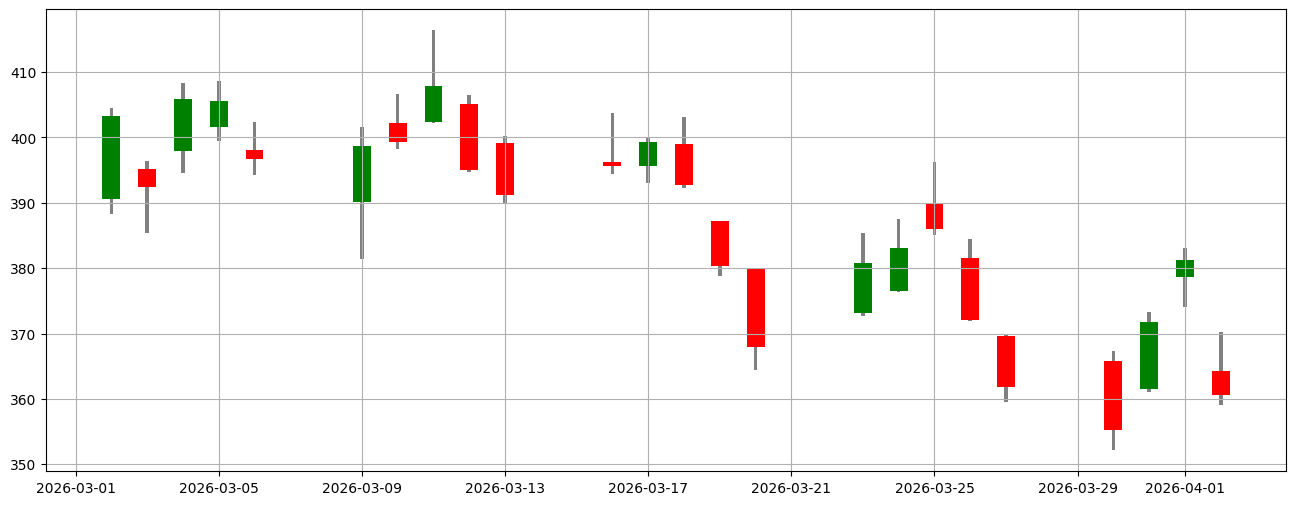

In [4]:
import datos
import importlib
importlib.reload(datos)

tsla_ohlc = datos.OHLC(data[data.index > pd.to_datetime("03-01-2026")])
tsla_ohlc.plot()

## Agregación de subpasos
En este apartado crearemos una serie de datos al minuto a partir de datos diarios. Después agregaremos los datos para crear el gráfico OHLC. 

In [5]:
gbm = SimulacionMonteCarlo.GBM()
gbm.ajustar_parametros(data['close'])

/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:127: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  new_params = {'T': ts.shape[0], 'N': ts.shape[0], 'Deltat':1., 'S0':ts[0], 'M':M}
/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  -(ts[k]-ts[k-1]*(1+var_mu*new_params['Deltat']))**2/
/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:132: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treat

Ajuste de parámetros realizado correctamente.


In [6]:
gbm.mostrar_parametros()

===== Parámetros del modelo =====
T:		1255
N:		1255
Deltat:		1.0
S0:		230.54
M:		1
mu:		0.0010464177183839962
sigma:		0.03722934392424106


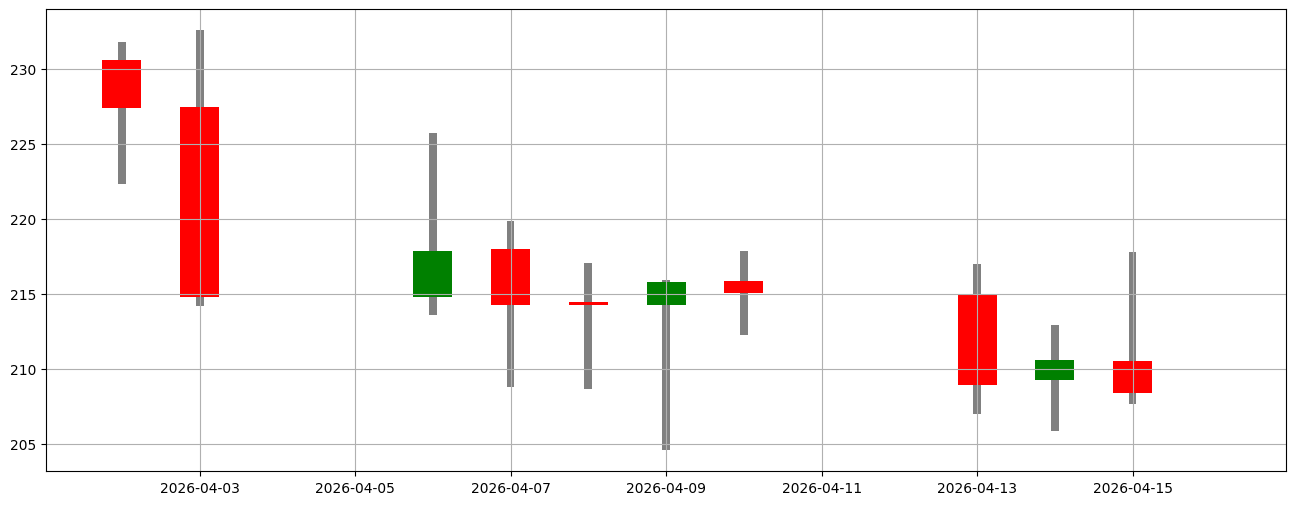

In [37]:
import datos 
importlib.reload(datos)
importlib.reload(SimulacionMonteCarlo)
from datetime import timedelta

gbm.cambiar_escala_temporal(N=10*24*60, Deltat=1/(24*60))
valores = gbm.simular().reshape(-1)
fechas = np.array(datos.next_k_bdates(k=10*24*60+1, start=data.index[-1], delta=timedelta(minutes=1)))
df = pd.DataFrame({'valores': valores})
df.index = fechas
df.index.names = ['fechas']
ohlc = datos.OHLC().desde_simulacion(df)
ohlc.plot()

## Modelado de volatilidad relativa
Tomaremos como precio de cierre el precio del día, el precio de apertura el precio de cierre del día anterior. Para simular el high/low, cogeremos el máximo/mínimo y le sumaremos/restaremos el valor absoluto de una variable normal con media cero y desviación estándar inferior a la de la serie. Nosotros tomaremos como desviación estándar la de la serie dividida por la raíz del número de fechas de la serie.

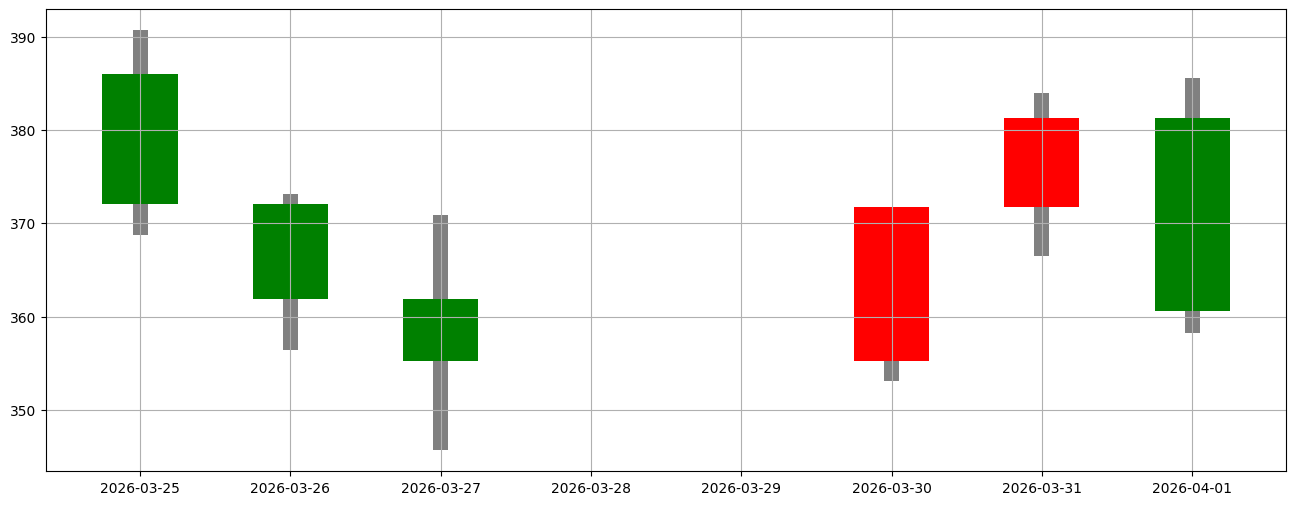

In [8]:
importlib.reload(datos)
ohlc = datos.OHLC().desde_volatilidad_relativa(data['close'].iloc[-11:])
ohlc.plot()

Hemos implementado una pequeña mejora: no usar una volatilidad constane para la variable normal generada, sino una desviación estandar rolling para que la volatilidad del high/low se adapte a las condiciones actuales de mercado.

## Interpolación con puentes brownianos


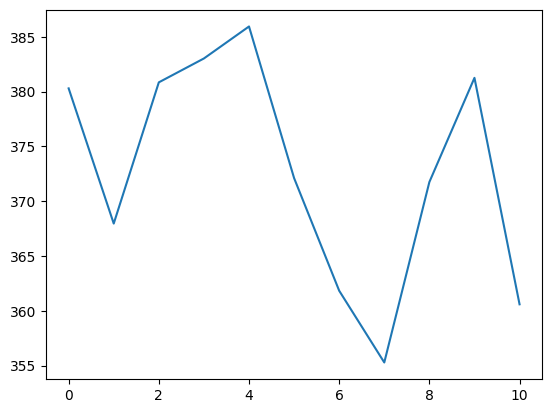

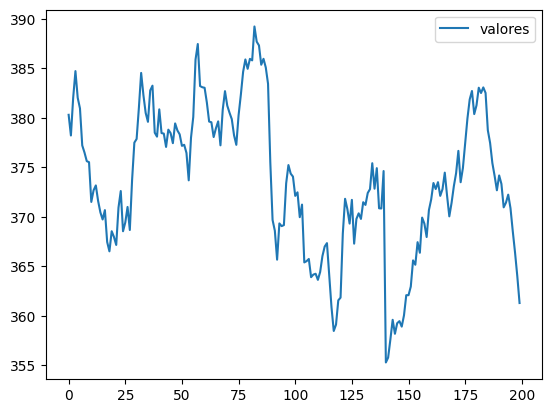

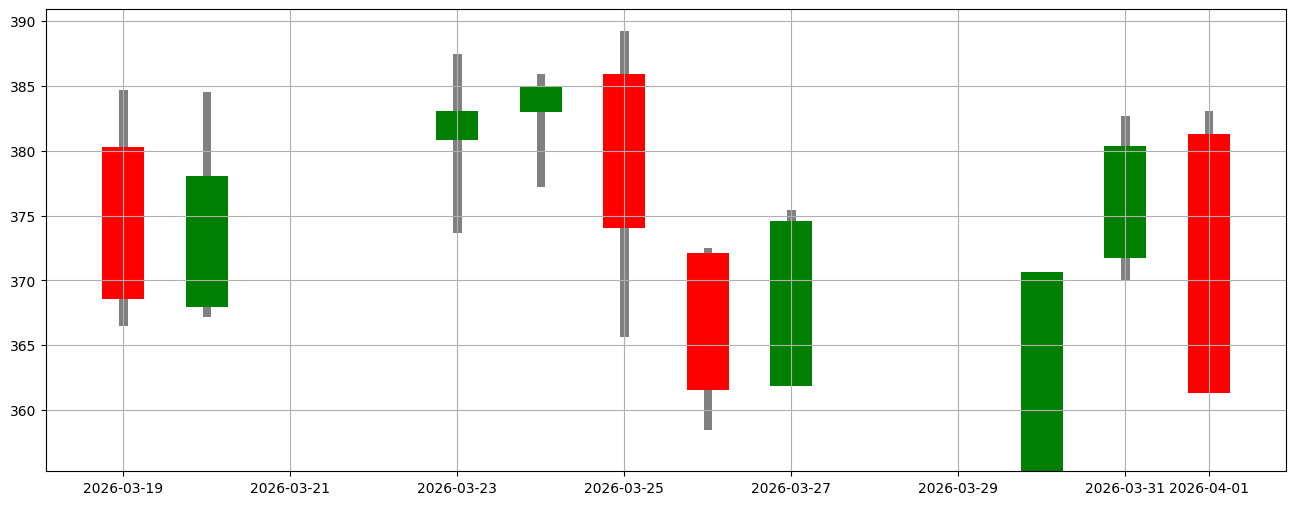

In [32]:
importlib.reload(datos)
ohlc = datos.OHLC().desde_interpolacion_puentes_brownianos(data['close'].iloc[-11:])
ohlc.plot()

NOTA: no se simula actividad en días festivos, lo cual no es necesariamente realista. Lo que sí que hace es respetar posibles saltos existentes en los datos. Por ejemplo si hay un salto en los datos con un fin de semana en medio, entonces no se generará un puente browniano entre las dos fechas, en el gráfico OHLC aparecerá como un salto al no haber un candle para ese día. En el gráfico anterior puede observarse esta casuística.